# Ridge Regularization:

---

In [1]:
import time

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_percentage_error

In [2]:
data = pd.read_csv("house_prices_preprocessed.csv")

In [3]:
data.drop(columns=['Unnamed: 0'], inplace=True)

## Train-Test-Split:

In [4]:
X = data.drop(columns=['SalePrice'])
y = data['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=69)

## Building Model using sklearn:

In [5]:
param = {'alpha' : [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

grid = GridSearchCV(
    estimator=Ridge(),
    scoring='r2',
    param_grid=param,
    n_jobs=-1,
    cv=5
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter indexes are also d

In [6]:
print(f"Best parameters: {grid.best_params_}")
print(f"Best Score: {grid.best_score_ * 100 :.2f}%")

Best parameters: {'alpha': 1}
Best Score: 83.84%


In [7]:
L2 = Ridge(alpha=1, solver='auto')

start_time = time.time()
L2.fit(X_train, y_train)
end_time = time.time() - start_time

print("Model Trained Successfully!")
print(f"Time Taken For Training: {end_time:.2f}s")

Model Trained Successfully!
Time Taken For Training: 0.01s


## Results:

In [8]:
y_pred = L2.predict(X_test)

print(f"r2 Score: {r2_score(y_test, y_pred)*100:.2f}%")
print(f"\nmean absolute error: {(mean_absolute_percentage_error(y_test, y_pred)*100):.2f}%")

r2 Score: 80.35%

mean absolute error: 9.14%


In [9]:
print(f"r2 Score: {np.mean(cross_val_score(estimator=L2, X=X, y=y, scoring='r2', cv=10, n_jobs=-1)) * 100:.2f}%")

r2 Score: 82.85%


In [10]:
print(f"mean absolute error: {-np.mean(cross_val_score(estimator=L2, X=X, y=y, scoring='neg_mean_absolute_percentage_error', cv=10, n_jobs=-1)) * 100:.2f}%")

mean absolute error: 9.65%


## Building Model using O.L.S. Method:

In [11]:
class ridge:

    def __init__(self, alpha):
        self.alpha = alpha
        self.intercept = None
        self.coef = None

    def fit(self, X_train, y_train):

        self.X_train = X_train
        self.y_train = y_train

        self.X_train = np.insert(self.X_train, 0, 1, axis=1)
        I = np.identity(self.X_train.shape[1])
        beta = np.linalg.inv(np.dot(self.X_train.T, self.X_train) + self.alpha * I).dot(self.X_train.T).dot(self.y_train)

        self.intercept = beta[0]
        self.coef = beta[1:]

    def predict(self, X_test):

        return self.intercept + np.dot(X_test, self.coef)

In [12]:
l2 = ridge(alpha=1)

start_time = time.time()
l2.fit(X_train, y_train)
end_time = time.time() - start_time

print("Model Trained Successfully!")
print(f"Time Taken For Training: {end_time:.2f}s")

Model Trained Successfully!
Time Taken For Training: 0.01s


In [13]:
y_pred = l2.predict(X_test)

print(f"r2 Score: {r2_score(y_test, y_pred)*100:.2f}%")
print(f"\nmean absolute error: {(mean_absolute_percentage_error(y_test, y_pred)*100):.2f}%")

r2 Score: 80.35%

mean absolute error: 9.18%


## Building Model using Gradient Descent:

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
class GDRidge:

    def __init__(self, learning_rate=0.01, max_iter=100, alpha=1):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.alpha = alpha
        self.intercept = None
        self.coef = None
        self.loss = []

    def fit(self, X_train, y_train):

        self.X_train = X_train
        self.y_train = y_train

        self.intercept = 0
        self.coef = np.zeros(self.X_train.shape[1])
        beta = np.insert(self.coef, 0, self.intercept)

        self.X_train = np.insert(self.X_train, 0, 1, axis=1)

        for i in range(self.max_iter):

            slope = (2 / self.X_train.shape[0]) * (np.dot(self.X_train.T, self.X_train).dot(beta) - np.dot(self.X_train.T, self.y_train))
            slope[1:] += 2 * self.alpha * beta[1:]
            beta = beta - (self.learning_rate * slope)

            loss = np.mean((self.y_train - np.dot(self.X_train, beta)) ** 2) + self.alpha * np.sum(beta[1:] ** 2)
            self.loss.append(loss)

        self.intercept = beta[0]
        self.coef = beta[1:]

    def predict(self, X_test):

        return self.intercept + np.dot(X_test, self.coef)

In [16]:
ridge = GDRidge(learning_rate=0.1, max_iter=100, alpha=0.01)

start_time = time.time()
ridge.fit(X_train_scaled, y_train)
end_time = time.time() - start_time

print("Model Trained Successfully!")
print(f"Time Taken For Training: {end_time:.2f}s")

Model Trained Successfully!
Time Taken For Training: 0.11s


In [17]:
y_pred = ridge.predict(X_test_scaled)

print(f"r2 Score: {r2_score(y_test, y_pred)*100:.2f}%")
print(f"\nmean absolute error: {(mean_absolute_percentage_error(y_test, y_pred)*100):.2f}%")

r2 Score: 80.29%

mean absolute error: 9.11%


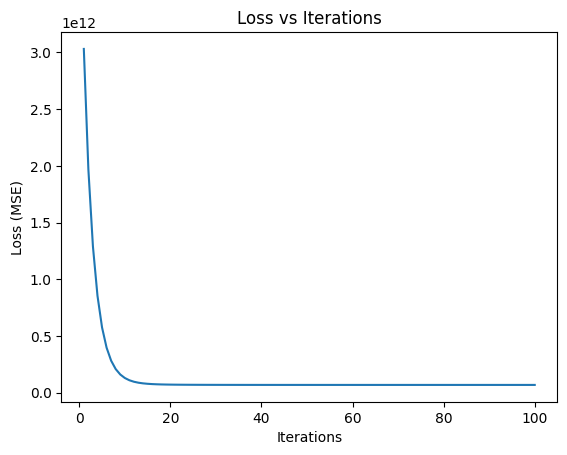

In [18]:
plt.plot(range(1, len(ridge.loss) + 1), ridge.loss)
plt.xlabel("Iterations")
plt.ylabel("Loss (MSE)")
plt.title("Loss vs Iterations")
plt.show()